In [4]:
!pip install pyts

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 16.8 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd 
import os

import matplotlib.pyplot as plt
from pyts.image import GramianAngularField






## read annotations

anno_label_dict = pd.read_csv('data/capture24/annotation-label-dictionary.csv',
                              index_col='annotation', dtype='string')
os.chdir ('data')


In [2]:
# for windoing the signal
def extract_windows(data, winsize='30s'):
    X, Y = [], []
    for t, w in data.resample(winsize, origin='start'):

        # Check window has no NaNs and is of correct length
        # 10s @ 100Hz = 1000 ticks
        if w.isna().any().any() or len(w) != 3000:
            continue

        x = w[['x', 'y', 'z']].to_numpy()
        y = w['label'].mode(dropna=False).item()
    
        X.append(x)
        Y.append(y)

    X = np.stack(X)
    Y = np.stack(Y)

    return X, Y

Found 151 files to process: ['P001.csv.gz', 'P002.csv.gz', 'P003.csv.gz', 'P004.csv.gz', 'P005.csv.gz', 'P006.csv.gz', 'P007.csv.gz', 'P008.csv.gz', 'P009.csv.gz', 'P010.csv.gz', 'P011.csv.gz', 'P012.csv.gz', 'P013.csv.gz', 'P014.csv.gz', 'P015.csv.gz', 'P016.csv.gz', 'P017.csv.gz', 'P018.csv.gz', 'P019.csv.gz', 'P020.csv.gz', 'P021.csv.gz', 'P022.csv.gz', 'P023.csv.gz', 'P024.csv.gz', 'P025.csv.gz', 'P026.csv.gz', 'P027.csv.gz', 'P028.csv.gz', 'P029.csv.gz', 'P030.csv.gz', 'P031.csv.gz', 'P032.csv.gz', 'P033.csv.gz', 'P034.csv.gz', 'P035.csv.gz', 'P036.csv.gz', 'P037.csv.gz', 'P038.csv.gz', 'P039.csv.gz', 'P040.csv.gz', 'P041.csv.gz', 'P042.csv.gz', 'P043.csv.gz', 'P044.csv.gz', 'P045.csv.gz', 'P046.csv.gz', 'P047.csv.gz', 'P048.csv.gz', 'P049.csv.gz', 'P050.csv.gz', 'P051.csv.gz', 'P052.csv.gz', 'P053.csv.gz', 'P054.csv.gz', 'P055.csv.gz', 'P056.csv.gz', 'P057.csv.gz', 'P058.csv.gz', 'P059.csv.gz', 'P060.csv.gz', 'P061.csv.gz', 'P062.csv.gz', 'P063.csv.gz', 'P064.csv.gz', 'P065.csv.g

KeyboardInterrupt: 

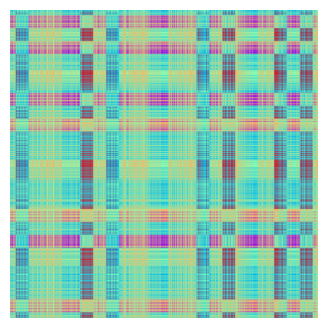

In [11]:

N=3000 # number of data points in each window
fig_w=4; fig_h=4;# figure width and height


path_data=r"C:\Users\Finla\OneDrive - University of Edinburgh\Diss\capture24\data\capture24" # data directory
path_GAF=r"C:\Users\Finla\OneDrive - University of Edinburgh\Diss\capture24\data\GAF" # where GAF images will be saved

#make GAF folder to save files into
# os.makedirs(path_GAF, exist_ok=True)

# working directory for data


directory_contents = [i for i in os.listdir(path_data) if i.endswith('.csv.gz')] # get the data file names
print(f"Found {len(directory_contents)} files to process: {directory_contents}") # comment out at end

print (directory_contents)
p_cnt=1
for j in (directory_contents):
    print(f"Processing: {j}")
    
    file_to_read = os.path.join(path_data, j)
    # read data
    data = pd.read_csv(file_to_read, index_col='time', parse_dates=['time'],
                       dtype={'x': 'f4', 'y': 'f4', 'z': 'f4', 'annotation': 'string'}) 
    #label data
    data['label'] = (anno_label_dict['label:Walmsley2020']
                 .reindex(data['annotation'])
                 .to_numpy())

    X, Y = extract_windows(data) # extract data


    img_cnt=1
    img_label_cnt=0
    for i in X:
        acc_x=i[:,0] # get x from the array
        acc_y=i[:,1] # get y from the array
        acc_z=i[:,2] # get z from the array
        acc_VM=np.sqrt((acc_x**2) + (acc_y**2) + (acc_z**2)) #compute vecor magnitude
        

        figure_name_GAF_X='P'+f"{p_cnt:03}"+'_'+str(img_cnt)+'_GAF_X'+'_'+Y[img_label_cnt]+'.jpg'
        figure_name_GAF_Y='P'+f"{p_cnt:03}"+'_'+str(img_cnt)+'_GAF_Y'+'_'+Y[img_label_cnt]+'.jpg'
        figure_name_GAF_Z='P'+f"{p_cnt:03}"+'_'+str(img_cnt)+'_GAF_Z'+'_'+Y[img_label_cnt]+'.jpg'
        figure_name_GAF_VM='P'+f"{p_cnt:03}"+'_'+str(img_cnt)+'_GAF_VM'+'_'+Y[img_label_cnt]+'.jpg'

        save_path_X = os.path.join(path_GAF, figure_name_GAF_X)
        save_path_Y = os.path.join(path_GAF, figure_name_GAF_Y)
        save_path_Z = os.path.join(path_GAF, figure_name_GAF_Z)
        save_path_VM = os.path.join(path_GAF, figure_name_GAF_VM)
            
        #plot X
        fig, axs = plt.subplots(1, 1, figsize=(fig_w,fig_h))
        plt.axis('off')
        X = np.array([acc_x])
        gadf = GramianAngularField(method='difference')
        X_gadf = gadf.fit_transform(X)

        axs.imshow(X_gadf[0],
                   cmap='rainbow',
                  origin='lower')
        axs.axis('off')
        plt.savefig(save_path_X, bbox_inches='tight',pad_inches = 0, dpi=100);
        print(j,img_cnt,figure_name_GAF_X) 
        fig.clf()
        plt.close() 


        #plot Y
        fig, axs = plt.subplots(1, 1, figsize=(fig_w,fig_h))
        plt.axis('off')
        X = np.array([acc_y])
        gadf = GramianAngularField(method='difference')
        X_gadf = gadf.fit_transform(X)

        axs.imshow(X_gadf[0],
                   cmap='rainbow',
                  origin='lower')
        axs.axis('off')
        plt.savefig(save_path_Y, bbox_inches='tight',pad_inches = 0, dpi=100);
        print(j,img_cnt,figure_name_GAF_Y) 
        fig.clf()
        plt.close() 

        
        #plot Z
        fig, axs = plt.subplots(1, 1, figsize=(fig_w,fig_h))
        plt.axis('off')
        X = np.array([acc_z])
        gadf = GramianAngularField(method='difference')
        X_gadf = gadf.fit_transform(X)

        axs.imshow(X_gadf[0],
                   cmap='rainbow',
                  origin='lower')
        axs.axis('off')
        plt.savefig(save_path_Z, bbox_inches='tight',pad_inches = 0, dpi=100);
        print(j,img_cnt,figure_name_GAF_Z) 
        fig.clf()
        plt.close()
        
             
                
        #plot VM
        fig, axs = plt.subplots(1, 1, figsize=(fig_w,fig_h))
        plt.axis('off')
        X = np.array([acc_VM])
        gadf = GramianAngularField(method='difference')
        X_gadf = gadf.fit_transform(X)

        axs.imshow(X_gadf[0],
                   cmap='rainbow',
                  origin='lower')
        axs.axis('off')
        plt.savefig(save_path_VM, bbox_inches='tight',pad_inches = 0, dpi=100);
        print(j,img_cnt,figure_name_GAF_VM) 
        fig.clf()
        plt.close()     
                
        img_cnt+=1
        img_label_cnt+=1

    p_cnt+=1 
    
